# Chapter 12: Reshaping Data with Pivot, Melt, Stack, Unstack, and Wide vs Long Formats

**Companion notebook** for *Beginner's Guide to Pandas* by Ravi Shankar

Run each cell in order. Exercises are at the end.

In [1]:
import pandas as pd
import numpy as np

# Reshaping Data with Pivot, Melt, Stack, Unstack, and Wide vs Long Formats

Data is rarely in the perfect shape for analysis. In this chapter, you'll learn how to reshape, pivot, melt, and tidy your data using pandas—making it easier to analyze, visualize, and share.

---

## Why Reshape and Tidy Data?

Real-world datasets often come in wide, messy, or nested formats. Before you can analyze data effectively, you frequently need to:

- Convert wide data to long format (and vice versa)
- Stack, unstack, and pivot tables
- Tidy data for visualization and modeling

Understanding *why* you're reshaping is just as important as knowing *how*. Data is often stored in formats that are efficient for collection or storage but awkward for analysis. Reshaping lets you convert between these formats so you can use pandas' powerful tools effectively.

---

## Understanding Data Formats: Wide vs Long

Data can be organized in two fundamental ways, each with distinct advantages.

### Wide Format

Wide format has observations spread across multiple columns. Each variable occupies its own column, making it easy to read at a glance but often harder to analyze programmatically.

In [2]:
import pandas as pd
import numpy as np

# Wide format example
wide_data = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-02', '2024-01-03'],
    'Temperature': [72, 75, 68],
    'Humidity': [45, 50, 55],
    'Pressure': [1013, 1012, 1015]
})

print(wide_data)

         Date  Temperature  Humidity  Pressure
0  2024-01-01           72        45      1013
1  2024-01-02           75        50      1012
2  2024-01-03           68        55      1015


Output:
```
         Date  Temperature  Humidity  Pressure
0  2024-01-01           72        45      1013
1  2024-01-02           75        50      1012
2  2024-01-03           68        55      1015
```

### Long Format

Long format stacks data vertically, with each row representing a single observation of one variable. This format is preferred for statistical analysis and visualization.

In [3]:
# Long format of the same data
long_data = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-01', '2024-01-01',
             '2024-01-02', '2024-01-02', '2024-01-02',
             '2024-01-03', '2024-01-03', '2024-01-03'],
    'Metric': ['Temperature', 'Humidity', 'Pressure'] * 3,
    'Value': [72, 45, 1013, 75, 50, 1012, 68, 55, 1015]
})

print(long_data)

         Date       Metric  Value
0  2024-01-01  Temperature     72
1  2024-01-01     Humidity     45
2  2024-01-01     Pressure   1013
3  2024-01-02  Temperature     75
4  2024-01-02     Humidity     50
5  2024-01-02     Pressure   1012
6  2024-01-03  Temperature     68
7  2024-01-03     Humidity     55
8  2024-01-03     Pressure   1015


Output:
```
         Date       Metric  Value
0  2024-01-01  Temperature     72
1  2024-01-01     Humidity     45
2  2024-01-01     Pressure   1013
3  2024-01-02  Temperature     75
4  2024-01-02     Humidity     50
5  2024-01-02     Pressure   1012
6  2024-01-03  Temperature     68
7  2024-01-03     Humidity     55
8  2024-01-03     Pressure   1015
```

### Why the Difference Matters

Consider a sales dataset. In wide format you might have:

```
Product | Jan_Sales | Feb_Sales | Mar_Sales
Widget  | 100       | 150       | 200
Gadget  | 50        | 75        | 100
```

If you want to analyze monthly trends, calculate growth rates, or create a time-series plot, you'd prefer long format:

```
Product | Month | Sales
Widget  | Jan   | 100
Widget  | Feb   | 150
Widget  | Mar   | 200
Gadget  | Jan   | 50
Gadget  | Feb   | 75
Gadget  | Mar   | 100
```

Long format makes grouping, filtering, and aggregation straightforward. Wide format is more human-readable and useful for certain reports and comparisons.

---

## Tidy Data Principles

Before diving into the reshaping functions, it helps to understand *tidy data*—a standard for organizing datasets that makes analysis predictable and efficient. Tidy data follows three rules:

1. **Each variable forms a column**
2. **Each observation forms a row**
3. **Each type of observational unit forms a table**

When your data follows these principles, you can use the same tools and techniques across different datasets without rewriting your code each time.

### Principle 1: Each Variable Forms a Column

A variable is a characteristic or measurement you're tracking—student name, test score, subject, date. Values that a variable *can take* (like "Math" or "English") should not appear as column headers.

In [4]:
# UNTIDY: Subjects are column headers (they are values, not variables)
untidy = pd.DataFrame({
    'Name': ['Alice', 'Bob'],
    'Math': [90, 78],
    'English': [85, 88]
})
print("Untidy format:")
print(untidy)

Untidy format:
    Name  Math  English
0  Alice    90       85
1    Bob    78       88


Output:
```
    Name  Math  English
0  Alice    90       85
1    Bob    78       88
```

In this untidy format, "Math" and "English" are values of the variable "Subject", not variables themselves.

In [5]:
# TIDY: Each row is one observation (one student, one subject)
tidy = pd.DataFrame({
    'Name': ['Alice', 'Alice', 'Bob', 'Bob'],
    'Subject': ['Math', 'English', 'Math', 'English'],
    'Score': [90, 85, 78, 88]
})
print("Tidy format:")
print(tidy)

Tidy format:
    Name  Subject  Score
0  Alice     Math     90
1  Alice  English     85
2    Bob     Math     78
3    Bob  English     88


Output:
```
    Name  Subject  Score
0  Alice     Math     90
1  Alice  English     85
2    Bob     Math     78
3    Bob  English     88
```

### Principle 2: Each Observation Forms a Row

An observation is a single instance of data collection. In student grades, one row should represent one student's score in one subject. In weather data, one row should represent one location at one point in time.

### Principle 3: Each Type of Observational Unit Forms a Table

If you have different types of entities—students, classes, teachers—they should live in separate tables linked by common identifiers.

In [6]:
# UNTIDY: Student and class info mixed in one table
untidy_mixed = pd.DataFrame({
    'StudentName': ['Alice', 'Bob', 'Alice', 'Bob'],
    'Score': [90, 78, 85, 88],
    'ClassName': ['Math 101', 'Math 101', 'English 102', 'English 102'],
    'ClassTeacher': ['Dr. Smith', 'Dr. Smith', 'Prof. Jones', 'Prof. Jones'],
    'ClassRoom': [201, 201, 305, 305]
})
print("Untidy (mixed observational units):")
print(untidy_mixed)

Untidy (mixed observational units):
  StudentName  Score    ClassName ClassTeacher  ClassRoom
0       Alice     90     Math 101    Dr. Smith        201
1         Bob     78     Math 101    Dr. Smith        201
2       Alice     85  English 102  Prof. Jones        305
3         Bob     88  English 102  Prof. Jones        305


Output:
```
  StudentName  Score    ClassName ClassTeacher  ClassRoom
0       Alice     90     Math 101    Dr. Smith        201
1         Bob     78     Math 101    Dr. Smith        201
2       Alice     85  English 102  Prof. Jones        305
3         Bob     88  English 102  Prof. Jones        305
```

Class information is repeated for every student, creating redundancy. If a teacher changes rooms, you must update multiple rows.

In [7]:
# TIDY: Separate tables for students and classes
students = pd.DataFrame({
    'StudentName': ['Alice', 'Bob', 'Alice', 'Bob'],
    'ClassID': [1, 1, 2, 2],
    'Score': [90, 78, 85, 88]
})

classes = pd.DataFrame({
    'ClassID': [1, 2],
    'ClassName': ['Math 101', 'English 102'],
    'ClassTeacher': ['Dr. Smith', 'Prof. Jones'],
    'ClassRoom': [201, 305]
})

print("Students Table:")
print(students)
print("\nClasses Table:")
print(classes)

Students Table:
  StudentName  ClassID  Score
0       Alice        1     90
1         Bob        1     78
2       Alice        2     85
3         Bob        2     88

Classes Table:
   ClassID    ClassName ClassTeacher  ClassRoom
0        1     Math 101    Dr. Smith        201
1        2  English 102  Prof. Jones        305


Output:
```
Students Table:
  StudentName  ClassID  Score
0       Alice        1     90
1         Bob        1     78
2       Alice        2     85
3         Bob        2     88

Classes Table:
   ClassID    ClassName ClassTeacher  ClassRoom
0        1     Math 101    Dr. Smith        201
1        2  English 102  Prof. Jones        305
```

Now teacher information lives in one place. Update it once, and it's correct everywhere.

---

## Melt: Converting Wide to Long

The `melt()` function transforms data from wide to long format by "unpivoting" columns into rows. It is one of the most commonly used reshaping tools.

### Basic Melt Syntax

In [8]:
# Simple melt: all non-id columns become variable-value pairs
melted = pd.melt(wide_data, id_vars=['Date'])
print(melted)

         Date     variable  value
0  2024-01-01  Temperature     72
1  2024-01-02  Temperature     75
2  2024-01-03  Temperature     68
3  2024-01-01     Humidity     45
4  2024-01-02     Humidity     50
5  2024-01-03     Humidity     55
6  2024-01-01     Pressure   1013
7  2024-01-02     Pressure   1012
8  2024-01-03     Pressure   1015


Output:
```
         Date     variable  value
0  2024-01-01  Temperature     72
1  2024-01-02  Temperature     75
2  2024-01-03  Temperature     68
3  2024-01-01     Humidity     45
4  2024-01-02     Humidity     50
5  2024-01-03     Humidity     55
6  2024-01-01     Pressure   1013
7  2024-01-02     Pressure   1012
8  2024-01-03     Pressure   1015
```

The key parameters are:
- `id_vars`: Columns to keep as identifiers (don't melt these)
- `value_vars`: Which columns to melt (defaults to all non-id columns)
- `var_name`: Name for the new column containing old header names
- `value_name`: Name for the new column containing the values

### Melt with Specific Columns and Custom Names

In [9]:
# Melt only specific columns, with descriptive column names
melted_specific = pd.melt(
    wide_data,
    id_vars=['Date'],
    value_vars=['Temperature', 'Humidity'],
    var_name='Weather_Metric',
    value_name='Measurement'
)

print(melted_specific)

         Date Weather_Metric  Measurement
0  2024-01-01    Temperature           72
1  2024-01-02    Temperature           75
2  2024-01-03    Temperature           68
3  2024-01-01       Humidity           45
4  2024-01-02       Humidity           50
5  2024-01-03       Humidity           55


Output:
```
         Date Weather_Metric  Measurement
0  2024-01-01    Temperature           72
1  2024-01-02    Temperature           75
2  2024-01-03    Temperature           68
3  2024-01-01       Humidity           45
4  2024-01-02       Humidity           50
5  2024-01-03       Humidity           55
```

### Melting Multiple Identifier Columns

You can preserve multiple columns as identifiers:

In [10]:
# Data with multiple identifiers
employee_data = pd.DataFrame({
    'employee_id': [1, 2, 3],
    'department': ['Sales', 'IT', 'HR'],
    'Q1_bonus': [500, 600, 400],
    'Q2_bonus': [550, 650, 450],
    'Q3_bonus': [600, 700, 500]
})

# Melt keeping both employee_id and department as identifiers
melted_emp = pd.melt(employee_data,
                     id_vars=['employee_id', 'department'],
                     var_name='quarter',
                     value_name='bonus')

print(melted_emp)

   employee_id department   quarter  bonus
0            1      Sales  Q1_bonus    500
1            2         IT  Q1_bonus    600
2            3         HR  Q1_bonus    400
3            1      Sales  Q2_bonus    550
4            2         IT  Q2_bonus    650
5            3         HR  Q2_bonus    450
6            1      Sales  Q3_bonus    600
7            2         IT  Q3_bonus    700
8            3         HR  Q3_bonus    500


Output:
```
   employee_id department   quarter  bonus
0            1      Sales  Q1_bonus    500
1            2         IT  Q1_bonus    600
2            3         HR  Q1_bonus    400
3            1      Sales  Q2_bonus    550
4            2         IT  Q2_bonus    650
5            3         HR  Q2_bonus    450
6            1      Sales  Q3_bonus    600
7            2         IT  Q3_bonus    700
8            3         HR  Q3_bonus    500
```

### Real-World Example: Sales Data

In [11]:
# Sales data in wide format
sales_wide = pd.DataFrame({
    'Region': ['North', 'South', 'East', 'West'],
    'Q1_Sales': [15000, 12000, 18000, 14000],
    'Q2_Sales': [16000, 13000, 19000, 15000],
    'Q3_Sales': [17000, 14000, 20000, 16000]
})

# Convert to long format for time-series analysis
sales_long = pd.melt(
    sales_wide,
    id_vars=['Region'],
    value_vars=['Q1_Sales', 'Q2_Sales', 'Q3_Sales'],
    var_name='Quarter',
    value_name='Sales'
)

print(sales_long)

   Region   Quarter  Sales
0   North  Q1_Sales  15000
1   South  Q1_Sales  12000
2    East  Q1_Sales  18000
3    West  Q1_Sales  14000
4   North  Q2_Sales  16000
5   South  Q2_Sales  13000
6    East  Q2_Sales  19000
7    West  Q2_Sales  15000
8   North  Q3_Sales  17000
9   South  Q3_Sales  14000
10   East  Q3_Sales  20000
11   West  Q3_Sales  16000


Output:
```
   Region   Quarter  Sales
0   North  Q1_Sales  15000
1   South  Q1_Sales  12000
2    East  Q1_Sales  18000
3    West  Q1_Sales  14000
4   North  Q2_Sales  16000
5   South  Q2_Sales  13000
6    East  Q2_Sales  19000
7    West  Q2_Sales  15000
8   North  Q3_Sales  17000
9   South  Q3_Sales  14000
10   East  Q3_Sales  20000
11   West  Q3_Sales  16000
```

---

## Pivot: Converting Long to Wide

The `pivot()` function is the inverse of `melt()`. It transforms data from long to wide format by specifying which columns become the index, columns, and values. It requires that each combination of index and column values be unique.

### Basic Pivot Syntax

In [12]:
# Convert the long sales data back to wide format
pivoted = sales_long.pivot(
    index='Region',
    columns='Quarter',
    values='Sales'
)

print(pivoted)

Quarter  Q1_Sales  Q2_Sales  Q3_Sales
Region                               
East        18000     19000     20000
North       15000     16000     17000
South       12000     13000     14000
West        14000     15000     16000


Output:
```
Quarter  Q1_Sales  Q2_Sales  Q3_Sales
Region
East        18000     19000     20000
North       15000     16000     17000
South       12000     13000     14000
West        14000     15000     16000
```

### Pivot with Multiple Value Columns

When you omit the `values` parameter, `pivot()` uses all remaining columns and creates a hierarchical column structure:

In [13]:
# Dataset with multiple metrics per observation
metrics = pd.DataFrame({
    'date': ['2024-01-01', '2024-01-01', '2024-01-02', '2024-01-02'],
    'store': ['Store A', 'Store B', 'Store A', 'Store B'],
    'units_sold': [50, 45, 55, 48],
    'avg_price': [25.50, 26.00, 25.75, 26.25]
})

# Pivot without specifying values creates hierarchical columns
multi_pivot = metrics.pivot(index='date', columns='store')
print(multi_pivot)

           units_sold         avg_price        
store         Store A Store B   Store A Store B
date                                           
2024-01-01         50      45     25.50   26.00
2024-01-02         55      48     25.75   26.25


Output:
```
           units_sold          avg_price
store       Store A  Store B    Store A  Store B
date
2024-01-01       50       45      25.50    26.00
2024-01-02       55       48      25.75    26.25
```

---

## Pivot Table: Handling Duplicates and Aggregation

When your data contains duplicate index/column combinations, `pivot()` will raise a `ValueError`. Use `pivot_table()` instead, which aggregates duplicate values using a function you specify.

In [14]:
# Data with duplicate entries — pivot() would fail here
transactions = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-01', '2024-01-01', '2024-01-02', '2024-01-02'],
    'Product': ['A', 'A', 'B', 'A', 'B'],
    'Amount': [100, 150, 200, 120, 180]
})

# pivot_table() aggregates duplicates
pivot_table_result = transactions.pivot_table(
    index='Date',
    columns='Product',
    values='Amount',
    aggfunc='sum'
)

print(pivot_table_result)

Product       A    B
Date                
2024-01-01  250  200
2024-01-02  120  180


Output:
```
Product      A    B
Date
2024-01-01  250  200
2024-01-02  120  180
```

### Common Aggregation Functions

In [15]:
# Count occurrences
count_table = transactions.pivot_table(
    index='Date',
    columns='Product',
    values='Amount',
    aggfunc='count'
)

# Average values
avg_table = transactions.pivot_table(
    index='Date',
    columns='Product',
    values='Amount',
    aggfunc='mean'
)

# Multiple aggregations at once
multi_agg = transactions.pivot_table(
    index='Date',
    columns='Product',
    values='Amount',
    aggfunc=['sum', 'mean', 'count']
)

print(multi_agg)

            sum        mean        count   
Product       A    B      A      B     A  B
Date                                       
2024-01-01  250  200  125.0  200.0     2  1
2024-01-02  120  180  120.0  180.0     1  1


The key difference to remember: `pivot()` fails on duplicates; `pivot_table()` handles them through aggregation.

---

## Stack and Unstack: Working with Hierarchical Indices

`stack()` and `unstack()` are designed to work with MultiIndex DataFrames. They provide powerful reshaping capabilities when your data has multiple levels of row or column labels.

### Understanding Stack

`stack()` pivots the innermost level of column labels to become the innermost level of row labels—converting columns into rows.

In [ ]:
# Create a DataFrame with hierarchical columns
df_multi = pd.DataFrame(
    np.random.randn(3, 4),
    index=['A', 'B', 'C'],
    columns=pd.MultiIndex.from_product(
        [['Group1', 'Group2'], ['X', 'Y']]
    )
)

print("Original DataFrame:")
print(df_multi)

# Stack: move innermost column level to rows
stacked = df_multi.stack(future_stack=True)
print("\nAfter stack():")
print(stacked)

### Understanding Unstack

`unstack()` is the inverse of `stack()`. It pivots a level of the row index to the column axis.

In [17]:
# Create a DataFrame with hierarchical row index
index = pd.MultiIndex.from_product(
    [['A', 'B'], ['X', 'Y']],
    names=['Letter', 'Symbol']
)
df_hierarchical = pd.DataFrame(
    np.random.randn(4, 2),
    index=index,
    columns=['Value1', 'Value2']
)

print("Original DataFrame:")
print(df_hierarchical)

# Unstack: move innermost row level to columns
unstacked = df_hierarchical.unstack()
print("\nAfter unstack():")
print(unstacked)

Original DataFrame:
                 Value1    Value2
Letter Symbol                    
A      X      -0.955141 -0.619547
       Y      -1.869730 -1.836795
B      X       0.158139 -0.717885
       Y      -0.325856 -0.196993

After unstack():
          Value1              Value2          
Symbol         X         Y         X         Y
Letter                                        
A      -0.955141 -1.869730 -0.619547 -1.836795
B       0.158139 -0.325856 -0.717885 -0.196993


### Unstacking Specific Levels

In [18]:
# Unstack a specific level by name
unstacked_letter = df_hierarchical.unstack(level='Letter')
print(unstacked_letter)

# Unstack by position (0 = outermost, -1 = innermost)
unstacked_inner = df_hierarchical.unstack(level=-1)
print(unstacked_inner)

          Value1              Value2          
Letter         A         B         A         B
Symbol                                        
X      -0.955141  0.158139 -0.619547 -0.717885
Y      -1.869730 -0.325856 -1.836795 -0.196993
          Value1              Value2          
Symbol         X         Y         X         Y
Letter                                        
A      -0.955141 -1.869730 -0.619547 -1.836795
B       0.158139 -0.325856 -0.717885 -0.196993


### Practical Stack/Unstack Example

In [19]:
# Performance metrics by department and month
performance = pd.DataFrame({
    'department': ['Sales', 'Sales', 'IT', 'IT', 'HR', 'HR'],
    'month': ['Jan', 'Feb', 'Jan', 'Feb', 'Jan', 'Feb'],
    'revenue': [50000, 55000, 0, 0, 0, 0],
    'efficiency': [0.85, 0.87, 0.92, 0.94, 0.88, 0.90]
})

# Set multi-level index
indexed = performance.set_index(['department', 'month'])
print("Indexed data:")
print(indexed)

# Stack to move column labels into row index
stacked_perf = indexed.stack()
print("\nStacked:")
print(stacked_perf)

# Unstack back to original structure
unstacked_perf = stacked_perf.unstack()
print("\nUnstacked back:")
print(unstacked_perf)

Indexed data:
                  revenue  efficiency
department month                     
Sales      Jan      50000        0.85
           Feb      55000        0.87
IT         Jan          0        0.92
           Feb          0        0.94
HR         Jan          0        0.88
           Feb          0        0.90

Stacked:
department  month            
Sales       Jan    revenue       50000.00
                   efficiency        0.85
            Feb    revenue       55000.00
                   efficiency        0.87
IT          Jan    revenue           0.00
                   efficiency        0.92
            Feb    revenue           0.00
                   efficiency        0.94
HR          Jan    revenue           0.00
                   efficiency        0.88
            Feb    revenue           0.00
                   efficiency        0.90
dtype: float64

Unstacked back:
                  revenue  efficiency
department month                     
HR         Feb        0.0     

---

## Practical Workflow: From Raw Data to Analysis

Here is a complete example showing how these operations work together in a realistic scenario.

In [20]:
# Step 1: Start with raw data in long format
raw_data = pd.DataFrame({
    'Student': ['Alice', 'Alice', 'Bob', 'Bob', 'Charlie', 'Charlie'],
    'Subject': ['Math', 'English', 'Math', 'English', 'Math', 'English'],
    'Score': [85, 90, 78, 88, 92, 85]
})

print("Step 1 - Raw Data (Long Format):")
print(raw_data)

# Step 2: Pivot to wide format for side-by-side comparison
grades_wide = raw_data.pivot(index='Student', columns='Subject', values='Score')
print("\nStep 2 - Pivoted to Wide Format:")
print(grades_wide)

# Step 3: Add a calculated column
grades_wide['Average'] = grades_wide.mean(axis=1)
print("\nStep 3 - With Average Column:")
print(grades_wide)

# Step 4: Melt back to long format for visualization
grades_long = pd.melt(
    grades_wide.reset_index(),
    id_vars=['Student'],
    var_name='Subject',
    value_name='Score'
)
print("\nStep 4 - Back to Long Format:")
print(grades_long)

Step 1 - Raw Data (Long Format):
   Student  Subject  Score
0    Alice     Math     85
1    Alice  English     90
2      Bob     Math     78
3      Bob  English     88
4  Charlie     Math     92
5  Charlie  English     85

Step 2 - Pivoted to Wide Format:
Subject  English  Math
Student               
Alice         90    85
Bob           88    78
Charlie       85    92

Step 3 - With Average Column:
Subject  English  Math  Average
Student                        
Alice         90    85     87.5
Bob           88    78     83.0
Charlie       85    92     88.5

Step 4 - Back to Long Format:
   Student  Subject  Score
0    Alice  English   90.0
1      Bob  English   88.0
2  Charlie  English   85.0
3    Alice     Math   85.0
4      Bob     Math   78.0
5  Charlie     Math   92.0
6    Alice  Average   87.5
7      Bob  Average   83.0
8  Charlie  Average   88.5


This pattern—long → wide for computation → long for visualization—is extremely common in real data workflows.

---

## Common Untidy Data Patterns and How to Fix Them

### Pattern 1: Column Headers as Values

The most common untidy pattern is when values (like subject names or dates) appear as column headers instead of as data.

In [21]:
# Untidy: subject names are column headers
untidy_scores = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Math_2024': [90, 78, 85],
    'English_2024': [85, 88, 92]
})

print("Untidy data:")
print(untidy_scores)

# Step 1: Melt to convert column headers to values
long = pd.melt(
    untidy_scores,
    id_vars=['Name'],
    var_name='Subject_Year',
    value_name='Score'
)

print("\nAfter melt:")
print(long)

Untidy data:
      Name  Math_2024  English_2024
0    Alice         90            85
1      Bob         78            88
2  Charlie         85            92

After melt:
      Name  Subject_Year  Score
0    Alice     Math_2024     90
1      Bob     Math_2024     78
2  Charlie     Math_2024     85
3    Alice  English_2024     85
4      Bob  English_2024     88
5  Charlie  English_2024     92


Output:
```
Untidy data:
      Name  Math_2024  English_2024
0    Alice         90            85
1      Bob         78            88
2  Charlie         85            92

After melt:
      Name  Subject_Year  Score
0    Alice     Math_2024     90
1      Bob     Math_2024     78
2  Charlie     Math_2024     85
3    Alice  English_2024     85
4      Bob  English_2024     88
5  Charlie  English_2024     92
```

In [22]:
# Step 2: Split the combined column name into separate variables
long[['Subject', 'Year']] = long['Subject_Year'].str.split('_', expand=True)

# Clean up
tidy_scores = long[['Name', 'Subject', 'Year', 'Score']]

print("Fully tidy data:")
print(tidy_scores)

Fully tidy data:
      Name  Subject  Year  Score
0    Alice     Math  2024     90
1      Bob     Math  2024     78
2  Charlie     Math  2024     85
3    Alice  English  2024     85
4      Bob  English  2024     88
5  Charlie  English  2024     92


Output:
```
      Name  Subject  Year  Score
0    Alice     Math  2024     90
1      Bob     Math  2024     78
2  Charlie     Math  2024     85
3    Alice  English  2024     85
4      Bob  English  2024     88
5  Charlie  English  2024     92
```

### Pattern 2: Multiple Variables in One Column

In [23]:
# Untidy: height and weight combined in one column
untidy_measurements = pd.DataFrame({
    'Name': ['Alice', 'Bob'],
    'Measurements': ['170cm_65kg', '180cm_75kg']
})

print("Untidy data:")
print(untidy_measurements)

# Split into separate columns
measurements_split = untidy_measurements['Measurements'].str.split('_', expand=True)
measurements_split.columns = ['Height', 'Weight']

tidy_measurements = pd.concat(
    [untidy_measurements[['Name']].reset_index(drop=True), measurements_split],
    axis=1
)

# Remove units and convert to numeric
tidy_measurements['Height_cm'] = pd.to_numeric(
    tidy_measurements['Height'].str.replace('cm', '').str.strip(),
    errors='coerce'
)
tidy_measurements['Weight_kg'] = pd.to_numeric(
    tidy_measurements['Weight'].str.replace('kg', '').str.strip(),
    errors='coerce'
)

tidy_measurements = tidy_measurements[['Name', 'Height_cm', 'Weight_kg']]

print("\nTidy data:")
print(tidy_measurements)

Untidy data:
    Name Measurements
0  Alice   170cm_65kg
1    Bob   180cm_75kg

Tidy data:
    Name  Height_cm  Weight_kg
0  Alice        170         65
1    Bob        180         75


Output:
```
Untidy data:
    Name Measurements
0  Alice   170cm_65kg
1    Bob   180cm_75kg

Tidy data:
    Name  Height_cm  Weight_kg
0  Alice        170         65
1    Bob        180         75
```

### Pattern 3: Missing Values in Tidy Data

Tidy data makes missing values explicit and easier to handle.

In [24]:
# Data with missing values in wide format
messy_with_na = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Math': [90, None, 85],
    'English': [85, 88, None]
})

print("Untidy with missing values:")
print(messy_with_na)

# Melt to long format
tidy_with_na = pd.melt(
    messy_with_na,
    id_vars=['Name'],
    var_name='Subject',
    value_name='Score'
)

print("\nTidy with missing values:")
print(tidy_with_na)

# Now you can handle missing values explicitly
print("\nRows with missing scores:")
print(tidy_with_na[tidy_with_na['Score'].isna()])

print("\nRows with complete data:")
print(tidy_with_na.dropna())

Untidy with missing values:
      Name  Math  English
0    Alice  90.0     85.0
1      Bob   NaN     88.0
2  Charlie  85.0      NaN

Tidy with missing values:
      Name  Subject  Score
0    Alice     Math   90.0
1      Bob     Math    NaN
2  Charlie     Math   85.0
3    Alice  English   85.0
4      Bob  English   88.0
5  Charlie  English    NaN

Rows with missing scores:
      Name  Subject  Score
1      Bob     Math    NaN
5  Charlie  English    NaN

Rows with complete data:
      Name  Subject  Score
0    Alice     Math   90.0
2  Charlie     Math   85.0
3    Alice  English   85.0
4      Bob  English   88.0


Output:
```
Untidy with missing values:
      Name  Math  English
0    Alice  90.0     85.0
1      Bob   NaN     88.0
2  Charlie  85.0      NaN

Tidy with missing values:
      Name  Subject  Score
0    Alice     Math   90.0
1      Bob     Math    NaN
2  Charlie     Math   85.0
3    Alice  English   85.0
4      Bob  English   88.0
5  Charlie  English    NaN

Rows with missing scores:
      Name  Subject  Score
1      Bob     Math    NaN
5  Charlie  English    NaN

Rows with complete data:
    Name  Subject  Score
0  Alice     Math   90.0
3  Alice  English   85.0
4    Bob  English   88.0
```

---

## Common Beginner Mistakes

### Mistake 1: Forgetting `expand=True` in `str.split()`

In [25]:
df = pd.DataFrame({'col': ['a_b_c', 'x_y_z', 'p_q_r']})

# Without expand=True: returns a Series of lists
result_wrong = df['col'].str.split('_')
print("Without expand=True:")
print(result_wrong)
print()

# With expand=True: returns a DataFrame with separate columns
result_correct = df['col'].str.split('_', expand=True)
print("With expand=True:")
print(result_correct)

Without expand=True:
0    [a, b, c]
1    [x, y, z]
2    [p, q, r]
Name: col, dtype: object

With expand=True:
   0  1  2
0  a  b  c
1  x  y  z
2  p  q  r


Output:
```
Without expand=True:
0    [a, b, c]
1    [x, y, z]
2    [p, q, r]
Name: col, dtype: object

With expand=True:
   0  1  2
0  a  b  c
1  x  y  z
2  p  q  r
```

Without `expand=True` you get a Series of lists, which is difficult to work with. With `expand=True` you get a proper DataFrame with separate columns you can name and use directly.

### Mistake 2: Not Specifying `id_vars` in `melt()`

In [26]:
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Math': [85, 90, 78],
    'Science': [88, 92, 85],
    'English': [90, 87, 92]
})

# Without id_vars: melts everything, including the Name identifier
wrong_melt = pd.melt(df)
print("Wrong melt (melts all columns):")
print(wrong_melt.head(6))
print()

# With id_vars: preserves Name as an identifier
correct_melt = pd.melt(df, id_vars=['Name'])
print("Correct melt (preserves 'Name' as identifier):")
print(correct_melt)

Wrong melt (melts all columns):
  variable    value
0     Name    Alice
1     Name      Bob
2     Name  Charlie
3     Math       85
4     Math       90
5     Math       78

Correct melt (preserves 'Name' as identifier):
      Name variable  value
0    Alice     Math     85
1      Bob     Math     90
2  Charlie     Math     78
3    Alice  Science     88
4      Bob  Science     92
5  Charlie  Science     85
6    Alice  English     90
7      Bob  English     87
8  Charlie  English     92


Output:
```
Wrong melt (melts all columns):
  variable    value
0     Name    Alice
1     Name      Bob
2     Name  Charlie
3     Math       85
4     Math       90
5     Math       78

Correct melt (preserves 'Name' as identifier):
      Name variable  value
0    Alice     Math     85
1      Bob     Math     90
2  Charlie     Math     78
3    Alice  Science     88
4      Bob  Science     92
5  Charlie  Science     85
6    Alice  English     90
7      Bob  English     87
8  Charlie  English     92
```

### Mistake 3: Assuming All Wide Data Is Untidy

Not all wide data is untidy. Some structures are properly wide by design and should not be forced into long format.

In [27]:
# A correlation matrix is properly wide — don't melt it
correlation_matrix = pd.DataFrame({
    'Math': [1.0, 0.8, 0.6],
    'English': [0.8, 1.0, 0.7],
    'Science': [0.6, 0.7, 1.0]
}, index=['Math', 'English', 'Science'])

print("Correlation matrix (properly wide):")
print(correlation_matrix)

Correlation matrix (properly wide):
         Math  English  Science
Math      1.0      0.8      0.6
English   0.8      1.0      0.7
Science   0.6      0.7      1.0


The structure of a correlation matrix is inherently two-dimensional. Converting it to long format would make it harder, not easier, to work with.

---

## How Tidy Data Helps Downstream Tasks

Once your data is tidy, common operations become straightforward.

### Grouping and Aggregation

In [28]:
tidy_scores = pd.DataFrame({
    'Name': ['Alice', 'Alice', 'Bob', 'Bob'],
    'Subject': ['Math', 'English', 'Math', 'English'],
    'Score': [90, 85, 78, 88]
})

# Groupby works intuitively on tidy data
print("Average score by subject:")
print(tidy_scores.groupby('Subject')['Score'].mean())

print("\nAverage score by student:")
print(tidy_scores.groupby('Name')['Score'].mean())

Average score by subject:
Subject
English    86.5
Math       84.0
Name: Score, dtype: float64

Average score by student:
Name
Alice    87.5
Bob      83.0
Name: Score, dtype: float64


Output:
```
Average score by subject:
Subject
English    86.5
Math       84.0
dtype: float64

Average score by student:
Name
Alice    87.5
Bob      83.0
dtype: float64
```

### Filtering

In [29]:
# Filter by subject — simple and readable
math_scores = tidy_scores[tidy_scores['Subject'] == 'Math']['Score']
english_scores = tidy_scores[tidy_scores['Subject'] == 'English']['Score']

print(f"Math mean: {math_scores.mean()}")
print(f"English mean: {english_scores.mean()}")

Math mean: 84.0
English mean: 86.5


Output:
```
Math mean: 84.0
English mean: 86.5
```

### Visualization

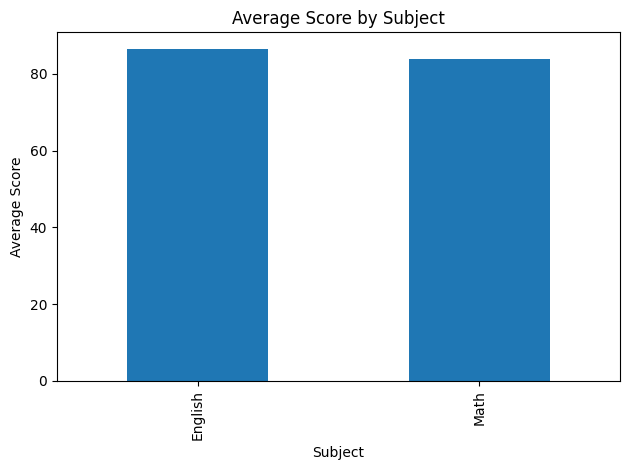

In [30]:
import matplotlib.pyplot as plt

# Tidy data works naturally with pandas plotting
tidy_scores.groupby('Subject')['Score'].mean().plot(kind='bar')
plt.title('Average Score by Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

---

## Choosing the Right Method

| Method | Input Format | Output Format | Use Case |
|--------|-------------|---------------|----------|
| `melt()` | Wide | Long | Preparing data for analysis, creating tidy datasets |
| `pivot()` | Long | Wide | Creating summary tables; requires unique index/column pairs |
| `pivot_table()` | Long | Wide | Aggregating duplicate entries, creating summaries |
| `stack()` | Wide (columns) | Long (rows) | Moving column levels to row index in hierarchical data |
| `unstack()` | Long (rows) | Wide (columns) | Moving row index levels to columns |

### Trade-offs: Long vs Wide Format

| Aspect | Long (Tidy) | Wide |
|--------|-------------|------|
| **Analysis** | Easier groupby, filtering | Easier comparisons, reporting |
| **Visualization** | Better for most plots | Better for heatmaps |
| **Readability** | Less human-readable | More human-readable |
| **Adding variables** | Add rows, not columns | Requires new columns |

**Default recommendation:** Use long format for analysis and transformation. Switch to wide format for specific reports, comparisons, or visualizations that require it.

---

## Best Practices

1. **Understand your data structure first.** Know whether your data is in long or wide format before reshaping, and know which format your analysis requires.

2. **Tidy before you analyze.** Invest time tidying your data at the start of a project. It pays dividends in every subsequent step.

3. **Use `melt()` for data preparation.** Long format is typically better for analysis, so use `melt()` to prepare wide data.

4. **Use `pivot_table()` over `pivot()` when in doubt.** It handles duplicates gracefully and is more flexible.

5. **Use `stack()` and `unstack()` for hierarchical data.** These methods are most powerful when working with MultiIndex DataFrames.

6. **Preserve original data.** Always assign reshaped data to new variables rather than modifying in place, so you can reference the original format if needed.

---

## Summary Checklist: Is Your Data Tidy?

- [ ] Each column represents exactly one variable
- [ ] Each row represents exactly one observation
- [ ] Each table contains one type of observational unit
- [ ] No column headers contain values (like "Math" or "English" as column names when they should be data)
- [ ] No cells contain multiple values (like "170cm_65kg")
- [ ] No information is redundantly repeated across rows
- [ ] Missing values are explicit (NaN), not hidden

---

## Key Takeaways

- **Long format** is ideal for statistical analysis, visualization, and most pandas operations
- **Wide format** is more human-readable and useful for certain reports and comparisons
- **`melt()`** converts wide to long by unpivoting columns into rows
- **`pivot()`** converts long to wide but requires unique index/column pairs
- **`pivot_table()`** handles duplicates through aggregation
- **`stack()` and `unstack()`** work with hierarchical indices to reshape data structure
- **Tidy data** follows three principles: each variable is a column, each observation is a row, each observational unit is a table
- Tidy data makes grouping, filtering, plotting, and statistical analysis straightforward and consistent

---

# Exercises

Test your understanding of this chapter's concepts.

### Exercise 1: Melt a Wide Sales Table to Long Format

You have a wide-format DataFrame where each column represents monthly sales for a product. Use pd.melt() to convert it into a long-format table where each row represents one product's sales in one month. Make sure the resulting columns are named 'Product', 'Month', and 'Sales'.

In [31]:
import pandas as pd

# Wide-format sales data
df_wide = pd.DataFrame({
    'Product': ['Apples', 'Bananas', 'Cherries'],
    'Jan': [150, 200, 90],
    'Feb': [180, 220, 110],
    'Mar': [170, 195, 130]
})

print('Original wide format:')
print(df_wide)
print()

# TODO: Use pd.melt() to convert df_wide to long format.
# - Keep 'Product' as the identifier column (id_vars)
# - The month column names should become values in a column called 'Month'
# - The sales numbers should go into a column called 'Sales'
df_long = None  # Replace None with your melt call

print('Melted long format:')
print(df_long)

Original wide format:
    Product  Jan  Feb  Mar
0    Apples  150  180  170
1   Bananas  200  220  195
2  Cherries   90  110  130

Melted long format:
None


### Exercise 2: Pivot Long Format Back to Wide

Starting from a long-format DataFrame containing student exam scores across multiple subjects, use df.pivot() to reshape it back into a wide-format table where each subject becomes its own column. The index should be the student name.

In [32]:
import pandas as pd

# Long-format exam scores
df_long = pd.DataFrame({
    'Student': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob', 'Bob', 'Carol', 'Carol', 'Carol'],
    'Subject': ['Math', 'Science', 'English', 'Math', 'Science', 'English', 'Math', 'Science', 'English'],
    'Score':   [88, 92, 75, 70, 85, 90, 95, 78, 82]
})

print('Original long format:')
print(df_long)
print()

# TODO: Use df.pivot() to reshape df_long so that:
# - 'Student' becomes the index
# - 'Subject' values become column names
# - 'Score' values fill the cells
# Store the result in df_wide
df_wide = None  # Replace None with your pivot call

# TODO: Reset the index so 'Student' becomes a regular column
# df_wide = ...

print('Pivoted wide format:')
print(df_wide)

Original long format:
  Student  Subject  Score
0   Alice     Math     88
1   Alice  Science     92
2   Alice  English     75
3     Bob     Math     70
4     Bob  Science     85
5     Bob  English     90
6   Carol     Math     95
7   Carol  Science     78
8   Carol  English     82

Pivoted wide format:
None


### Exercise 3: Summarise Duplicate Data with Pivot Table

A store recorded every individual transaction in a log. Because customers made multiple purchases, a simple pivot() would fail due to duplicate entries. Use pd.pivot_table() to create a summary showing the total revenue and average quantity per customer per product category.

In [33]:
import pandas as pd

# Transaction log with duplicates
df = pd.DataFrame({
    'Customer': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob', 'Carol', 'Carol', 'Carol'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Electronics', 'Clothing', 'Electronics'],
    'Revenue':  [300, 50, 150, 80, 200, 400, 60, 100],
    'Quantity': [1, 2, 1, 3, 1, 2, 1, 1]
})

print('Raw transaction log:')
print(df)
print()

# TODO: Create a pivot table using pd.pivot_table() with:
# - 'Customer' as the index
# - 'Category' as the columns
# - 'Revenue' and 'Quantity' as the values
# - Total (sum) for Revenue and mean for Quantity
# - Fill missing combinations with 0
# Hint: pass a dictionary to aggfunc, e.g. {'Revenue': 'sum', 'Quantity': 'mean'}
pivot = None  # Replace None with your pivot_table call

print('Pivot table summary:')
print(pivot)

Raw transaction log:
  Customer     Category  Revenue  Quantity
0    Alice  Electronics      300         1
1    Alice     Clothing       50         2
2    Alice  Electronics      150         1
3      Bob     Clothing       80         3
4      Bob  Electronics      200         1
5    Carol  Electronics      400         2
6    Carol     Clothing       60         1
7    Carol  Electronics      100         1

Pivot table summary:
None


### Exercise 4: Stack and Unstack a Multi-Level DataFrame

You are given a DataFrame with a two-level column hierarchy representing quarterly sales by region and product line. Practice using stack() to move the innermost column level into the row index, then use unstack() to reverse the operation and restore the original shape.

In [34]:
import pandas as pd

# Build a DataFrame with a MultiLevel column index
cols = pd.MultiIndex.from_tuples([
    ('North', 'Hardware'), ('North', 'Software'),
    ('South', 'Hardware'), ('South', 'Software')
], names=['Region', 'Product'])

df = pd.DataFrame(
    [[120, 300, 95, 210],
     [140, 320, 105, 230],
     [130, 310, 100, 220]],
    index=['Q1', 'Q2', 'Q3'],
    columns=cols
)
df.index.name = 'Quarter'

print('Original wide DataFrame with MultiLevel columns:')
print(df)
print()

# TODO: Use .stack() to move the 'Product' level (innermost column level)
# from the columns into the row index.
# Store the result in df_stacked.
df_stacked = None  # Replace None with your stack call

print('After stacking the Product level:')
print(df_stacked)
print()

# TODO: Use .unstack() on df_stacked to move 'Product' back to the columns,
# restoring the original shape. Store the result in df_restored.
df_restored = None  # Replace None with your unstack call

print('After unstacking (restored shape):')
print(df_restored)
print()

# TODO: Verify the restored DataFrame equals the original using .equals()
# Print True if they match, False otherwise.
# print(...)

Original wide DataFrame with MultiLevel columns:
Region     North             South         
Product Hardware Software Hardware Software
Quarter                                    
Q1           120      300       95      210
Q2           140      320      105      230
Q3           130      310      100      220

After stacking the Product level:
None

After unstacking (restored shape):
None



---

# Solutions

*Scroll down only after you've attempted the exercises above.*

<br><br><br><br><br><br><br><br><br><br>

### Solution 1: Melt a Wide Sales Table to Long Format

In [35]:
import pandas as pd
import numpy as np

# Wide-format sales data
df_wide = pd.DataFrame({
    'Product': ['Apples', 'Bananas', 'Cherries'],
    'Jan': [150, 200, 90],
    'Feb': [180, 220, 110],
    'Mar': [170, 195, 130]
})

print('Original wide format:')
print(df_wide)
print()

# Use pd.melt() to convert df_wide to long format
df_long = pd.melt(
    df_wide,
    id_vars='Product',
    var_name='Month',
    value_name='Sales'
)

print('Melted long format:')
print(df_long)

Original wide format:
    Product  Jan  Feb  Mar
0    Apples  150  180  170
1   Bananas  200  220  195
2  Cherries   90  110  130

Melted long format:
    Product Month  Sales
0    Apples   Jan    150
1   Bananas   Jan    200
2  Cherries   Jan     90
3    Apples   Feb    180
4   Bananas   Feb    220
5  Cherries   Feb    110
6    Apples   Mar    170
7   Bananas   Mar    195
8  Cherries   Mar    130


### Solution 2: Pivot Long Format Back to Wide

In [36]:
import pandas as pd
import numpy as np

# Long-format exam scores
df_long = pd.DataFrame({
    'Student': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob', 'Bob', 'Carol', 'Carol', 'Carol'],
    'Subject': ['Math', 'Science', 'English', 'Math', 'Science', 'English', 'Math', 'Science', 'English'],
    'Score':   [88, 92, 75, 70, 85, 90, 95, 78, 82]
})

print('Original long format:')
print(df_long)
print()

# Use df.pivot() to reshape df_long
df_wide = df_long.pivot(
    index='Student',
    columns='Subject',
    values='Score'
)

# Reset the index so 'Student' becomes a regular column
df_wide = df_wide.reset_index()

# Optional: remove the column axis name for cleaner output
df_wide.columns.name = None

print('Pivoted wide format:')
print(df_wide)

Original long format:
  Student  Subject  Score
0   Alice     Math     88
1   Alice  Science     92
2   Alice  English     75
3     Bob     Math     70
4     Bob  Science     85
5     Bob  English     90
6   Carol     Math     95
7   Carol  Science     78
8   Carol  English     82

Pivoted wide format:
  Student  English  Math  Science
0   Alice       75    88       92
1     Bob       90    70       85
2   Carol       82    95       78


### Solution 3: Summarise Duplicate Data with Pivot Table

In [37]:
import pandas as pd
import numpy as np

# Transaction log with duplicates
df = pd.DataFrame({
    'Customer': ['Alice', 'Alice', 'Alice', 'Bob', 'Bob', 'Carol', 'Carol', 'Carol'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Electronics', 'Clothing', 'Electronics'],
    'Revenue':  [300, 50, 150, 80, 200, 400, 60, 100],
    'Quantity': [1, 2, 1, 3, 1, 2, 1, 1]
})

print('Raw transaction log:')
print(df)
print()

# Create a pivot table
pivot = pd.pivot_table(
    df,
    index='Customer',
    columns='Category',
    values=['Revenue', 'Quantity'],
    aggfunc={'Revenue': 'sum', 'Quantity': 'mean'},
    fill_value=0
)

print('Pivot table summary:')
print(pivot)

Raw transaction log:
  Customer     Category  Revenue  Quantity
0    Alice  Electronics      300         1
1    Alice     Clothing       50         2
2    Alice  Electronics      150         1
3      Bob     Clothing       80         3
4      Bob  Electronics      200         1
5    Carol  Electronics      400         2
6    Carol     Clothing       60         1
7    Carol  Electronics      100         1

Pivot table summary:
         Quantity              Revenue            
Category Clothing Electronics Clothing Electronics
Customer                                          
Alice         2.0         1.0       50         450
Bob           3.0         1.0       80         200
Carol         1.0         1.5       60         500


### Solution 4: Stack and Unstack a Multi-Level DataFrame

In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame with a MultiLevel column index
cols = pd.MultiIndex.from_tuples([
    ('North', 'Hardware'), ('North', 'Software'),
    ('South', 'Hardware'), ('South', 'Software')
], names=['Region', 'Product'])

df = pd.DataFrame(
    [[120, 300, 95, 210],
     [140, 320, 105, 230],
     [130, 310, 100, 220]],
    index=['Q1', 'Q2', 'Q3'],
    columns=cols
)
df.index.name = 'Quarter'

print('Original wide DataFrame with MultiLevel columns:')
print(df)
print()

# Use .stack() to move the 'Product' level into the row index
df_stacked = df.stack(level='Product', future_stack=True)

print('After stacking the Product level:')
print(df_stacked)
print()

# Use .unstack() to move 'Product' back to the columns
df_restored = df_stacked.unstack(level='Product')

print('After unstacking (restored shape):')
print(df_restored)
print()

# Verify the restored DataFrame equals the original
print('Restored DataFrame matches original:', df_restored.equals(df))